# Analyse network

## Setup and helpers

In [16]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa
import yaml

runs = [
    # "ac_dc_dist",
    # "ac_dc_solar_dist",
    # "ac_dc_solar_wind_dist",
    # "ac_dc_solar_wind_dist_heat_dh0",
    # "ac_dc_solar_wind_dist_heat_dh06",
    # "ac_dc_solar_wind_dist_heat_dh06_tes_ates",
    # "ac_dc_vre_dist_heat_dh06",
    # "ac_dc_vre_dist_heat_dh06_tes",
    # "ac_dc_vre_dist_tnspt_heat_dh06",
    # "ac_dc_vre_dist_tnspt_dsm_heat_dh06",
    # "ac_dc_vre_dist_tnspt_dsm_v2g_heat_dh06",
    # "ac_dc_vre_dstbtn_tnspt_heat_fssl_ocgt_ccgt_gas+net",
    # "ac_dc_vre_dstbtn_tnspt_heat",
    # "ac_dc_vre_dstbtn_tnspt_heat_bmss2",
    # "ac_dc_vre_dstbtn_tnspt_heat_bmss_indstr",
    # "ac_dc_vre_dstbtn_tnspt_heat_indstr_bmss_ccgt_gas",
    # "ac_dc_vre_dstbtn_tnspt_heat_bmss_indstr_ff",
    # "ac_dc_vre_dstbtn_tnspt_heat_bmss_indstr_ff_dac",
    "ac_dc_vre_dstbtn_tnspt_heat_bmss_indstr_ff_dac_gasnet",
    "ac_dc_vre_dstbtn_tnspt_heat_bmss_indstr_meth_dac_gasnet",
]

run_name = {}
clusters = {}
wildcard_opts = {}
resolved_name = {}
pypsa_config = {}
n = {}
stats_table = {}
stats = {}

clusters[runs[0]] = "2"
clusters[runs[1]] = "2"
# clusters[runs[2]] = "3"
wildcard_opts[runs[0]] = ""
wildcard_opts[runs[1]] = ""
# wildcard_opts[runs[2]] = ""


for run in runs:
    resolved_name[run] = f"base_s_{clusters[run]}__{wildcard_opts[run]}_2050"

    with open(f"results/{run}/configs/config.{resolved_name[run]}.yaml") as f:
        pypsa_config[run] = yaml.safe_load(f)

    n[run] = pypsa.Network(f"results/{run}/networks/{resolved_name[run]}.nc")

    # Plotting settings
    tech_colors = pypsa_config[run]["plotting"]["tech_colors"]
    nice_names = pypsa_config[run]["plotting"]["nice_names"]

    stats[run] = n[run].statistics
    stats_table[run] = n[run].statistics(drop_zero=False, nice_names=False, round=3)

INFO:pypsa.network.io:New version 1.0.7 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.7 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


### Helpers

In [17]:
def stacked_barh_signed(
    data,
    ax,
    *,
    tech_colors=None,
    nice_names=None,
    y_label="Total",
    group_labels=None,
    annotate_thresh=0.03,
    annotate_decimals=0,
    title=None,
    group_bracket_height=0.15,  # Height above bar for group brackets
    bar_height=0.6,
    group_label_font_size=9,
    show_legend=True,
):
    """
    Plot horizontal stacked bars robust to negative values.

    Parameters
    ----------
    - data: pandas Series OR dict of Series
      - If Series with MultiIndex: single stacked bar with grouped bracket annotations
      - If Series with single index: single stacked bar (original behavior)
      - If dict: single stacked bar with grouped bracket annotations above
    - ax: matplotlib axis
    - tech_colors: dict carrier -> color (fallback '#888888')
    - nice_names: dict carrier -> pretty label
    - y_label: str, text for the y-axis label
    - group_labels: dict {group_key: label}, nice labels for group annotations (for dict/MultiIndex data)
    - annotate_thresh: fraction threshold for showing labels
    - annotate_decimals: number of decimal places for annotations (default 0)
    - title: optional plot title
    - group_bracket_height: vertical offset for group bracket annotations
    - bar_height: height of the bar
    - show_legend: bool, whether to display the legend (default True)
    """
    if tech_colors is None:
        tech_colors = {}
    if nice_names is None:
        nice_names = {}
    if group_labels is None:
        group_labels = {}

    # Check if data is MultiIndex Series
    is_multiindex = isinstance(data, pd.Series) and isinstance(data.index, pd.MultiIndex)

    # Handle both Series and dict inputs
    if isinstance(data, dict) or is_multiindex:
        # Single stacked bar with group annotations
        legend_handles = {}

        # Track cumulative positions for positive and negative values separately
        left_pos_positive = 0.0  # Tracks rightward stacking from 0
        left_pos_negative = 0.0  # Tracks leftward stacking from 0

        # Store group boundaries separately for positive and negative portions
        # {group_key: {'pos': (start_x, end_x), 'neg': (start_x, end_x)}}
        group_boundaries = {}

        if is_multiindex:
            # Get unique group keys from first level
            group_keys = data.index.get_level_values(0).unique()
        else:
            # Dict case
            group_keys = data.keys()

        for group_key in group_keys:
            # Extract series for this group
            if is_multiindex:
                series = data.xs(group_key, level=0)
            else:
                series = data[group_key]

            series = series.dropna()

            # Split into positive and negative values (keep zeros with positives)
            pos_series = series[series >= 0].sort_values(ascending=False)
            neg_series = series[series < 0].sort_values(ascending=True)  # Sort ascending for leftward stacking

            # Initialize boundaries for this group
            group_boundaries[group_key] = {'pos': None, 'neg': None}

            # --- Handle positive values (stack rightward) ---
            if len(pos_series) > 0:
                group_start_pos = left_pos_positive
                total_pos = pos_series.sum()

                for carrier, value in pos_series.items():
                    color = tech_colors.get(carrier, "#888888")
                    label = nice_names.get(carrier, carrier)

                    ax.barh(
                        0, value, left=left_pos_positive, height=bar_height, 
                        color=color, edgecolor="white"
                    )

                    # Annotate if above threshold
                    if total_pos > 0 and (value / total_pos) >= annotate_thresh:
                        ax.text(
                            left_pos_positive + value / 2,
                            0,
                            f"{value:.{annotate_decimals}f}",
                            ha="center",
                            va="center",
                            fontsize=8,
                        )

                    left_pos_positive += value

                    # Add to legend (avoid duplicates)
                    if label not in legend_handles:
                        legend_handles[label] = mpatches.Patch(color=color, label=label)

                group_boundaries[group_key]['pos'] = (group_start_pos, left_pos_positive)

            # --- Handle negative values (stack leftward) ---
            if len(neg_series) > 0:
                group_start_neg = left_pos_negative
                total_neg_abs = abs(neg_series.sum())

                for carrier, value in neg_series.items():
                    color = tech_colors.get(carrier, "#888888")
                    label = nice_names.get(carrier, carrier)

                    ax.barh(
                        0, value, left=left_pos_negative, height=bar_height, 
                        color=color, edgecolor="white"
                    )

                    # Annotate if above threshold
                    if total_neg_abs > 0 and (abs(value) / total_neg_abs) >= annotate_thresh:
                        ax.text(
                            left_pos_negative + value / 2,
                            0,
                            f"{value:.{annotate_decimals}f}",
                            ha="center",
                            va="center",
                            fontsize=8,
                        )

                    left_pos_negative += value

                    # Add to legend (avoid duplicates)
                    if label not in legend_handles:
                        legend_handles[label] = mpatches.Patch(color=color, label=label)

                group_boundaries[group_key]['neg'] = (left_pos_negative, group_start_neg)

        # Draw group brackets/annotations
        y_bracket_pos = bar_height / 2 + group_bracket_height  # Above bar
        y_bracket_neg = -bar_height / 2 - group_bracket_height  # Below bar

        for group_key, boundaries in group_boundaries.items():
            group_label = group_labels.get(group_key, group_key)

            # Draw positive bracket (above bar)
            if boundaries['pos'] is not None:
                x_start, x_end = boundaries['pos']
                if x_end - x_start > 1e-6:  # Skip empty groups
                    x_mid = (x_start + x_end) / 2

                    # Draw horizontal line (bracket)
                    ax.plot(
                        [x_start, x_end],
                        [y_bracket_pos, y_bracket_pos],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Draw vertical ticks at ends
                    tick_height = 0.04
                    ax.plot(
                        [x_start, x_start],
                        [y_bracket_pos - tick_height, y_bracket_pos + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )
                    ax.plot(
                        [x_end, x_end],
                        [y_bracket_pos - tick_height, y_bracket_pos + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Add group label above bracket
                    ax.text(
                        x_mid,
                        y_bracket_pos + 0.08,
                        group_label,
                        ha="center",
                        va="bottom",
                        fontsize=group_label_font_size,
                        fontweight="normal",
                        clip_on=False
                    )

            # Draw negative bracket (below bar)
            if boundaries['neg'] is not None:
                x_start, x_end = boundaries['neg']
                if x_end - x_start > 1e-6:  # Skip empty groups
                    x_mid = (x_start + x_end) / 2

                    # Draw horizontal line (bracket)
                    ax.plot(
                        [x_start, x_end],
                        [y_bracket_neg, y_bracket_neg],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Draw vertical ticks at ends
                    tick_height = 0.04
                    ax.plot(
                        [x_start, x_start],
                        [y_bracket_neg - tick_height, y_bracket_neg + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )
                    ax.plot(
                        [x_end, x_end],
                        [y_bracket_neg - tick_height, y_bracket_neg + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Add group label below bracket
                    ax.text(
                        x_mid,
                        y_bracket_neg - 0.08,
                        group_label,
                        ha="center",
                        va="top",
                        fontsize=group_label_font_size,
                        fontweight="normal",
                        clip_on=False
                    )

        # Set axis properties
        ax.set_yticks([0])
        ax.set_yticklabels([y_label])
        ax.axvline(0, color="k", lw=0.8, alpha=0.4)

        # Set x-limits with padding for both positive and negative
        xmax = left_pos_positive
        xmin = left_pos_negative
        pad = 0.05 * max(abs(xmax), abs(xmin), 1e-12)
        ax.set_xlim(xmin - pad, xmax + pad)

        # Adjust y-limits to show both upper and lower brackets
        ax.set_ylim(y_bracket_neg - 0.25, y_bracket_pos + 0.25)

    else:
        # Single bar (original behavior)
        legend_handles = {}
        _plot_single_bar(
            data,
            ax,
            0,
            tech_colors,
            nice_names,
            annotate_thresh,
            bar_height,
            legend_handles,
            annotate_decimals,
        )
        ax.set_yticks([0])
        ax.set_yticklabels([y_label])

    if title:
        ax.set_title(title, pad=20)

    # Create legend from collected handles
    if show_legend and legend_handles:
        ax.legend(
            handles=list(legend_handles.values()),
            title="Carrier",
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
        )


def _plot_single_bar(
    s, ax, y_pos, tech_colors, nice_names, annotate_thresh, bar_height, legend_handles, annotate_decimals=0
):
    """Helper function to plot a single stacked bar at given y position."""
    s = s.dropna()
    pos = s[s > 0].sort_values(ascending=False)
    neg = s[s < 0].sort_values()

    total_pos = pos.sum()
    total_neg_abs = (-neg).sum()

    left_pos = 0.0
    left_neg = 0.0

    # Plot positives (to the right)
    for key, v in pos.items():
        color = tech_colors.get(key, "#888888")
        label = nice_names.get(key, key)
        ax.barh(
            y_pos, v, left=left_pos, height=bar_height, color=color, edgecolor="white"
        )

        if total_pos > 0 and (v / total_pos) >= annotate_thresh:
            ax.text(
                left_pos + v / 2,
                y_pos,
                f"{v:.{annotate_decimals}f}",
                ha="center",
                va="center",
                fontsize=8,
            )
        left_pos += v

        # Add to legend (avoid duplicates)
        if label not in legend_handles:
            legend_handles[label] = mpatches.Patch(color=color, label=label)

    # Plot negatives (to the left)
    for key, v in neg.items():
        color = tech_colors.get(key, "#888888")
        label = nice_names.get(key, key)
        ax.barh(
            y_pos, v, left=left_neg, height=bar_height, color=color, edgecolor="white"
        )

        if total_neg_abs > 0 and ((-v) / total_neg_abs) >= annotate_thresh:
            ax.text(
                left_neg + v / 2,
                y_pos,
                f"{v:.{annotate_decimals}f}",
                ha="center",
                va="center",
                fontsize=8,
            )
        left_neg += v

        if label not in legend_handles:
            legend_handles[label] = mpatches.Patch(color=color, label=label)

    # Draw zero reference line
    ax.axvline(0, color="k", lw=0.8, alpha=0.4, zorder=1)

    # Set x-limits with padding
    xmax = max(0.0, left_pos)
    xmin = min(0.0, left_neg)

    # Update ax limits if needed (don't shrink)
    current_xlim = ax.get_xlim()
    pad = 0.05 * max(xmax, abs(xmin), 1e-12)
    new_xlim = (min(current_xlim[0], xmin - pad), max(current_xlim[1], xmax + pad))
    ax.set_xlim(new_xlim)


def enforce_common_xlim(axes, data_list, pad_fraction=0.05):
    """
    Enforce a common x-axis limit across multiple axes when sharex=True.

    Parameters
    ----------
    - axes: array of matplotlib axes
    - data_list: list of pandas Series OR dicts of Series corresponding to each axis
    - pad_fraction: fraction of max range to add as padding (default 0.05)

    Returns
    -------
    - tuple: (xmin, xmax) the computed common limits
    """
    # Flatten data: convert dicts to concatenated Series
    all_series = []
    for data in data_list:
        if isinstance(data, dict):
            # Concatenate all Series in the dict
            all_series.append(pd.concat(data.values()))
        else:
            # Already a Series (including MultiIndex)
            all_series.append(data)

    # Calculate max positive and negative values across all data
    max_pos = max((s[s > 0].sum() if (s > 0).any() else 0) for s in all_series)
    max_neg = max((abs(s[s < 0].sum()) if (s < 0).any() else 0) for s in all_series)

    # Add padding
    pad = pad_fraction * max(max_pos, max_neg, 1e-12)
    xmin = -(max_neg + pad)
    xmax = max_pos + pad

    # Apply to all axes
    for a in axes:
        a.set_xlim(xmin, xmax)

    return xmin, xmax


def plot_comparison_barh(
    data,
    ax,
    *,
    lower_col=None,
    upper_col=None,
    tech_colors=None,
    nice_names=None,
    group_labels=None,
    xlabel="Value",
    title=None,
    bar_height=0.6,
    group_label_font_size=9,
    marker_size=4,
    show_legend=True,
    annotate_decimals=1,
    annotate_font_size=8,
    axis_limit=None,
):
    """
    Plot horizontal bars comparing two columns with group brackets on y-axis.

    Parameters
    ----------
    - data: DataFrame with MultiIndex (group, item) and at least 2 columns for comparison
    - ax: matplotlib axis
    - lower_col: str or int, column name/index for lower bound (shown as 'x' marker). If None, uses first column
    - upper_col: str or int, column name/index for upper bound (shown as full bar). If None, uses second column
    - tech_colors: dict item -> color (fallback '#888888'). Uses second-level index for lookup
    - nice_names: dict item -> pretty label. Uses second-level index for lookup
    - group_labels: dict {group_key: label}, nice labels for group annotations
    - xlabel: str, label for x-axis
    - title: optional plot title
    - bar_height: height of the bars
    - group_label_font_size: font size for group labels
    - marker_size: size of the 'x' marker for lower bound values
    - show_legend: bool, whether to display the legend (default True)
    - annotate_decimals: number of decimal places for bar annotations (default 1)
    - annotate_font_size: font size for bar value annotations (default 8)
    - axis_limit: optional x-axis limit. If a single number is provided, sets (0, limit) or (-limit, limit) if data has negatives. If a 2-tuple/list is provided, uses (xmin, xmax).
    """
    if tech_colors is None:
        tech_colors = {}
    if nice_names is None:
        nice_names = {}
    if group_labels is None:
        group_labels = {}

    # Determine which columns to use
    if lower_col is None:
        lower_col = data.columns[0]
    if upper_col is None:
        upper_col = data.columns[1] if len(data.columns) > 1 else data.columns[0]

    # Get unique groups in their original order
    groups = data.index.get_level_values(0).unique()

    # Build y-positions and group boundaries
    y_pos = 0
    group_boundaries = {}
    y_positions = []  # List of (item, y_position, label) tuples

    for group in groups:
        group_data = data.xs(group, level=0)
        group_start = y_pos

        for item in group_data.index:
            label = nice_names.get(item, item)
            y_positions.append((item, y_pos, label))
            y_pos += 1

        group_boundaries[group] = (group_start, y_pos - 1)

    # Calculate max and min values
    df = data[[lower_col, upper_col]]
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    max_val = df.max().max()
    min_val = df.min().min()

    if max_val == 0 or pd.isna(max_val):
        max_val = 1  # Avoid division by zero

    # Check if there are any negative values
    has_negative = min_val < 0 if pd.notna(min_val) else False

    # Determine x-axis limits early (used to clamp markers/labels when axis_limit is set)
    if has_negative:
        # Has negative values - center around 0
        x_min = min_val - abs(min_val) * 0.05
        x_max = max_val * 1.05
    else:
        # No negative values - start at 0
        x_min = 0
        x_max = max_val * 1.05

    # Optional override for x-axis limits
    if axis_limit is not None:
        if isinstance(axis_limit, (tuple, list, np.ndarray)) and len(axis_limit) == 2:
            x_min, x_max = axis_limit
        else:
            axis_limit = float(axis_limit)
            if has_negative:
                x_min, x_max = -abs(axis_limit), abs(axis_limit)
            else:
                x_min, x_max = 0, axis_limit

    x_span = max(float(x_max) - float(x_min), 1e-12)

    # Plot bars
    for item, y, label in y_positions:
        # Find the item in the original dataframe
        # Need to search through all groups to find it
        for group in groups:
            try:
                group_data = data.xs(group, level=0)
                if item in group_data.index:
                    color = tech_colors.get(item, "#888888")

                    lower_val = group_data.loc[item, lower_col]
                    upper_val = group_data.loc[item, upper_col]

                    if np.isinf(upper_val):
                        ax.text(
                            0,
                            y,
                            " Infinity!",
                            ha="left",
                            va="center",
                            fontsize=annotate_font_size,
                            clip_on=True,
                        )

                    elif pd.isna(upper_val):
                        ax.text(
                            0,
                            y,
                            " NaN/None",
                            ha="left",
                            va="center",
                            fontsize=annotate_font_size,
                            clip_on=True,
                        )

                    elif upper_val == 0:
                        ax.text(
                            upper_val,
                            y,
                            " Not installed",
                            ha="left",
                            va="center",
                            fontsize=annotate_font_size,
                            clip_on=True,
                        )

                    else:
                        # Plot upper bound as full opaque bar
                        ax.barh(
                            y,
                            upper_val,
                            height=bar_height,
                            color=color,
                            edgecolor="white",
                            linewidth=0.5,
                        )

                        # Annotate bar with its value to the right
                        overflow = False
                        if pd.notna(upper_val) and np.isfinite(upper_val):
                            if upper_val >= 0 and upper_val > x_max:
                                overflow = True
                            elif upper_val < 0 and upper_val < x_min:
                                overflow = True

                        if overflow:
                            # If the bar exceeds the visible range, place label at the bar base
                            if upper_val >= 0:
                                x_text = 0 if (x_min <= 0 <= x_max) else x_min
                                x_text = x_text + 0.01 * x_span
                                ha_text = "left"
                            else:
                                x_text = 0 if (x_min <= 0 <= x_max) else x_max
                                x_text = x_text - 0.01 * x_span
                                ha_text = "right"
                        else:
                            x_text = upper_val
                            ha_text = "left" if upper_val >= 0 else "right"

                        ax.text(
                            x_text,
                            y,
                            f" {upper_val:.{annotate_decimals}f}",
                            ha=ha_text,
                            va="center",
                            fontsize=annotate_font_size,
                            clip_on=True,
                        )

                    # Plot lower bound as 'x' marker
                    if pd.notna(lower_val) and np.isfinite(lower_val):
                        # Clamp marker to visible range so it stays on-axis when axis_limit is used
                        clamped_lower = min(max(lower_val, x_min), x_max)
                        ax.plot(
                            clamped_lower,
                            y,
                            marker="x",
                            color="black",
                            markersize=marker_size,
                            markeredgewidth=1.5,
                            linestyle="",
                        )
                    break
            except KeyError:
                continue

    # Set axis properties first to get proper tick label positions
    y_ticks = [y for _, y, _ in y_positions]
    y_labels = [label for _, _, label in y_positions]

    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)
    ax.set_ylim(-0.5, y_pos - 0.5)

    # Apply x-axis limits
    # if np.isinf(x_max):
    #     x_max = 1
    # if np.isinf(x_min):
    #     x_min = 0

    ax.set_xlim(x_min, x_max)

    # Force axis to draw so we can get label positions
    ax.figure.canvas.draw()

    # Compute a bracket offset in *pixels* from the longest y-tick label and apply it
    # as a fixed (points/inches) translation. This stays stable under tight_layout and subplots.
    import matplotlib.transforms as mtransforms

    try:
        renderer = ax.figure.canvas.get_renderer()
        tick_bboxes = [
            lbl.get_window_extent(renderer=renderer)
            for lbl in ax.get_yticklabels()
            if lbl.get_text()
        ]
        if tick_bboxes:
            leftmost_display = min(bb.x0 for bb in tick_bboxes)
            ax_left_display = ax.bbox.x0
            pad_px = 10  # pixel padding between tick labels and bracket
            bracket_x_display = leftmost_display - pad_px
            offset_px = bracket_x_display - ax_left_display  # negative => left of axes
            offset_in = offset_px / ax.figure.dpi
        else:
            offset_in = -0.15  # fallback inches
    except Exception:
        offset_in = -0.15

    # x in axes fraction (x=0 is the axes left spine), y in data
    base_transform = mtransforms.blended_transform_factory(ax.transAxes, ax.transData)
    bracket_transform = base_transform + mtransforms.ScaledTranslation(
        offset_in, 0, ax.figure.dpi_scale_trans
    )

    # Small constant-size tick and label paddings (in points)
    tick_dx_in = (6 / 72)
    label_dx_in = (10 / 72)
    label_transform = bracket_transform + mtransforms.ScaledTranslation(
        -label_dx_in, 0, ax.figure.dpi_scale_trans
    )

    # Draw group brackets on the left
    for group, (y_start, y_end) in group_boundaries.items():
        if y_end >= y_start:  # Skip empty groups
            y_mid = (y_start + y_end) / 2

            # Draw vertical line (bracket)
            ax.plot(
                [0, 0],
                [y_start - 0.5, y_end + 0.5],
                color="black",
                linewidth=1.5,
                clip_on=False,
                transform=bracket_transform,
            )

            # Draw horizontal ticks at ends
            ax.plot(
                [-(tick_dx_in * ax.figure.dpi) / ax.bbox.width, (tick_dx_in * ax.figure.dpi) / ax.bbox.width],
                [y_start - 0.5, y_start - 0.5],
                color="black",
                linewidth=1.5,
                clip_on=False,
                transform=bracket_transform,
            )
            ax.plot(
                [-(tick_dx_in * ax.figure.dpi) / ax.bbox.width, (tick_dx_in * ax.figure.dpi) / ax.bbox.width],
                [y_end + 0.5, y_end + 0.5],
                color="black",
                linewidth=1.5,
                clip_on=False,
                transform=bracket_transform,
            )

            # Add group label to the left of bracket
            group_label = group_labels.get(group, group)
            ax.text(
                0,
                y_mid,
                group_label,
                ha="right",
                va="center",
                fontsize=group_label_font_size,
                fontweight="normal",
                clip_on=False,
                transform=label_transform,
                rotation=90,
            )

    ax.set_xlabel(xlabel)

    if title:
        ax.set_title(title)

    # Create custom legend
    if show_legend:
        from matplotlib.lines import Line2D

        legend_elements = [
            mpatches.Patch(facecolor="gray", label=upper_col),
            Line2D(
                [0],
                [0],
                marker="x",
                color="black",
                label=lower_col,
                markersize=marker_size,
                markeredgewidth=1.5,
                linestyle="",
            ),
        ]
        ax.legend(handles=legend_elements, loc="lower right")



In [18]:
from collections.abc import Mapping
from typing import Literal


def new_rows_statistics_tables(
    tables: Mapping[str, pd.DataFrame],
    *,
    baseline: str | Literal["first", "previous"] = "previous",
    order: list[str] | None = None,
    keep_empty: bool = False,
    as_dataframe: bool = False,
    sort_index: bool = True,
    run_name: str = "run",
    baseline_name: str = "baseline",
) -> dict[str, pd.DataFrame] | pd.DataFrame:
    """
    Return rows present in each run's table but absent in the baseline table (by index).

    - baseline="previous": compare each run to the previous run in `order` (first run omitted).
    - baseline="first": compare each run to the first run in `order`/insertion order.
    - baseline=<run>: compare each run to a specific run name.
    """
    if not tables:
        return pd.DataFrame() if as_dataframe else {}

    if order is None:
        order = list(tables.keys())
    missing = [r for r in order if r not in tables]
    if missing:
        raise KeyError(f"Runs in `order` missing from tables: {missing}")

    if baseline == "previous":
        pairs = [(order[i], order[i - 1]) for i in range(1, len(order))]
    else:
        base_run = order[0] if baseline == "first" else baseline
        if base_run not in tables:
            raise KeyError(f"Baseline run '{base_run}' not found. Available: {list(tables.keys())}")
        pairs = [(run, base_run) for run in order]

    out: dict[str, pd.DataFrame] = {}
    base_for: dict[str, str] = {}
    for run, base in pairs:
        df = tables[run]
        base_index = tables[base].index
        new_rows = df.loc[~df.index.isin(base_index)]
        if sort_index and len(new_rows) > 0:
            new_rows = new_rows.sort_index()
        if keep_empty or len(new_rows) > 0:
            out[run] = new_rows
            base_for[run] = base

    if as_dataframe:
        if not out:
            return pd.DataFrame()
        combined = pd.concat(out, names=[run_name])
        combined[baseline_name] = combined.index.get_level_values(run_name).map(base_for)
        cols = [baseline_name] + [c for c in combined.columns if c != baseline_name]
        return combined[cols]

    return out


## Statistics

In [19]:
# New rows in `n[run].statistics(...)` vs previous run (by index presence)
tables = {
    run: n[run].statistics(drop_zero=False, nice_names=False, round=3)
    for run in runs
}

new_vs_prev = new_rows_statistics_tables(tables, baseline="previous", order=runs)

for run, prev in zip(runs[1:], runs[:-1]):
    print(f"\n=== {run} (new vs {prev}) ===")
    display(new_vs_prev.get(run, pd.DataFrame()))


=== ac_dc_vre_dstbtn_tnspt_heat_bmss_indstr_meth_dac_gasnet (new vs ac_dc_vre_dstbtn_tnspt_heat_bmss_indstr_ff_dac_gasnet) ===


,,Optimal Capacity,Installed Capacity,Supply,Withdrawal,Energy Balance,Transmission,Capacity Factor,Curtailment,Capital Expenditure,Operational Expenditure,Revenue,Market Value
Link,Sabatier,11072.116,0.0,0.0,6.817138e+07,-6.817138e+07,0.0,0.702858,0.0,5.726662e+08,635211.062,-1.108555e+10,-inf


### Energy balance

Text(0.5, 0, 'Energy [TWh]')

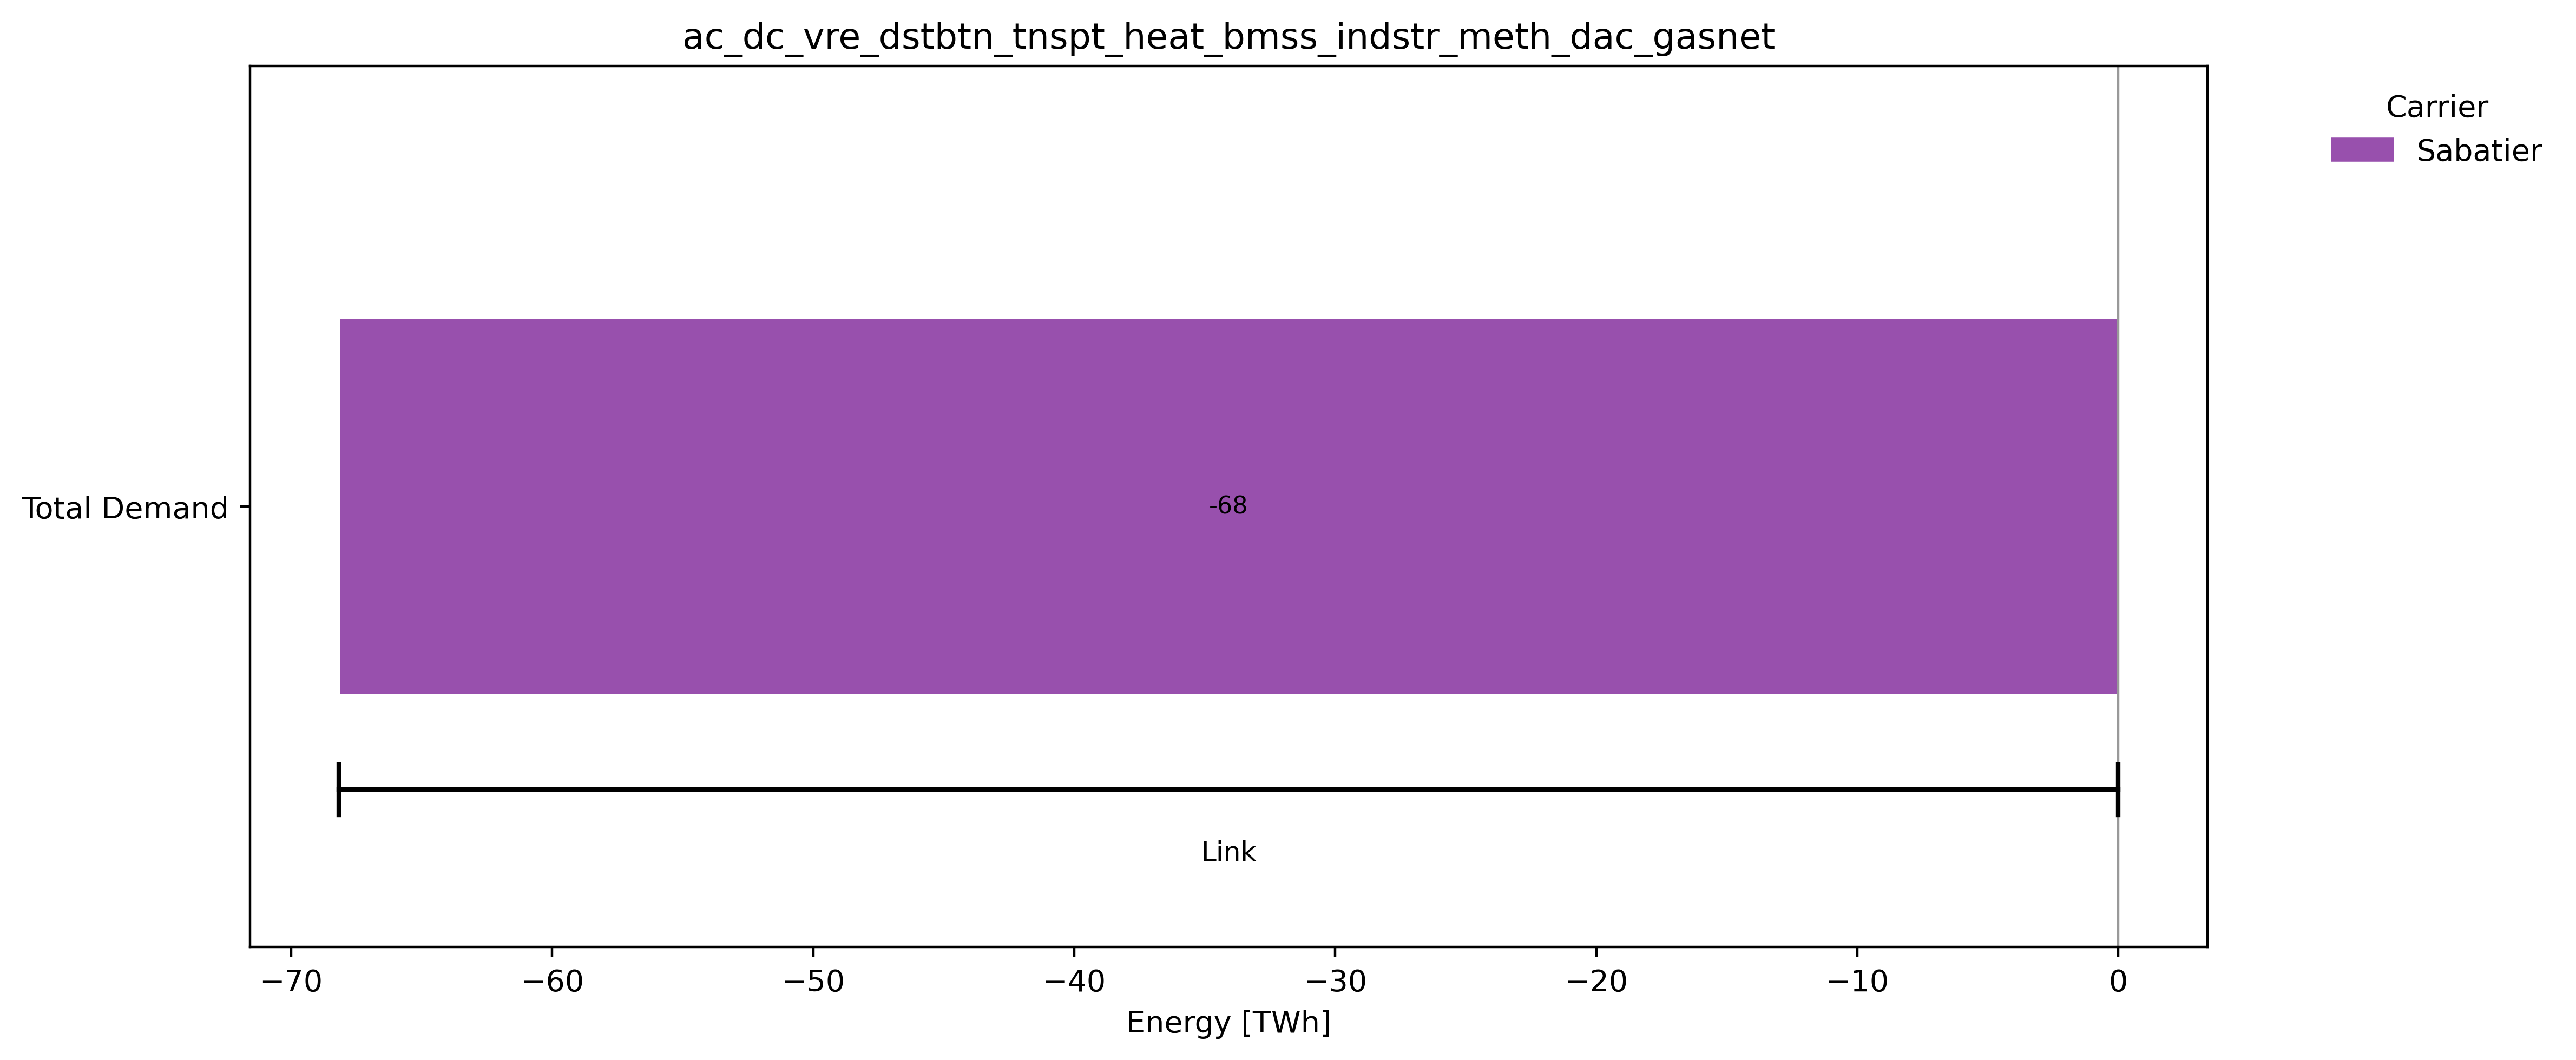

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

eb = new_vs_prev.get(run, pd.DataFrame())["Energy Balance"]

eb

stacked_barh_signed(
    eb / 1e6,  # TWh
    ax,
    tech_colors=tech_colors,
    y_label="Total Demand",
)

ax.set_title(f"{run}")
ax.set_xlabel("Energy [TWh]")

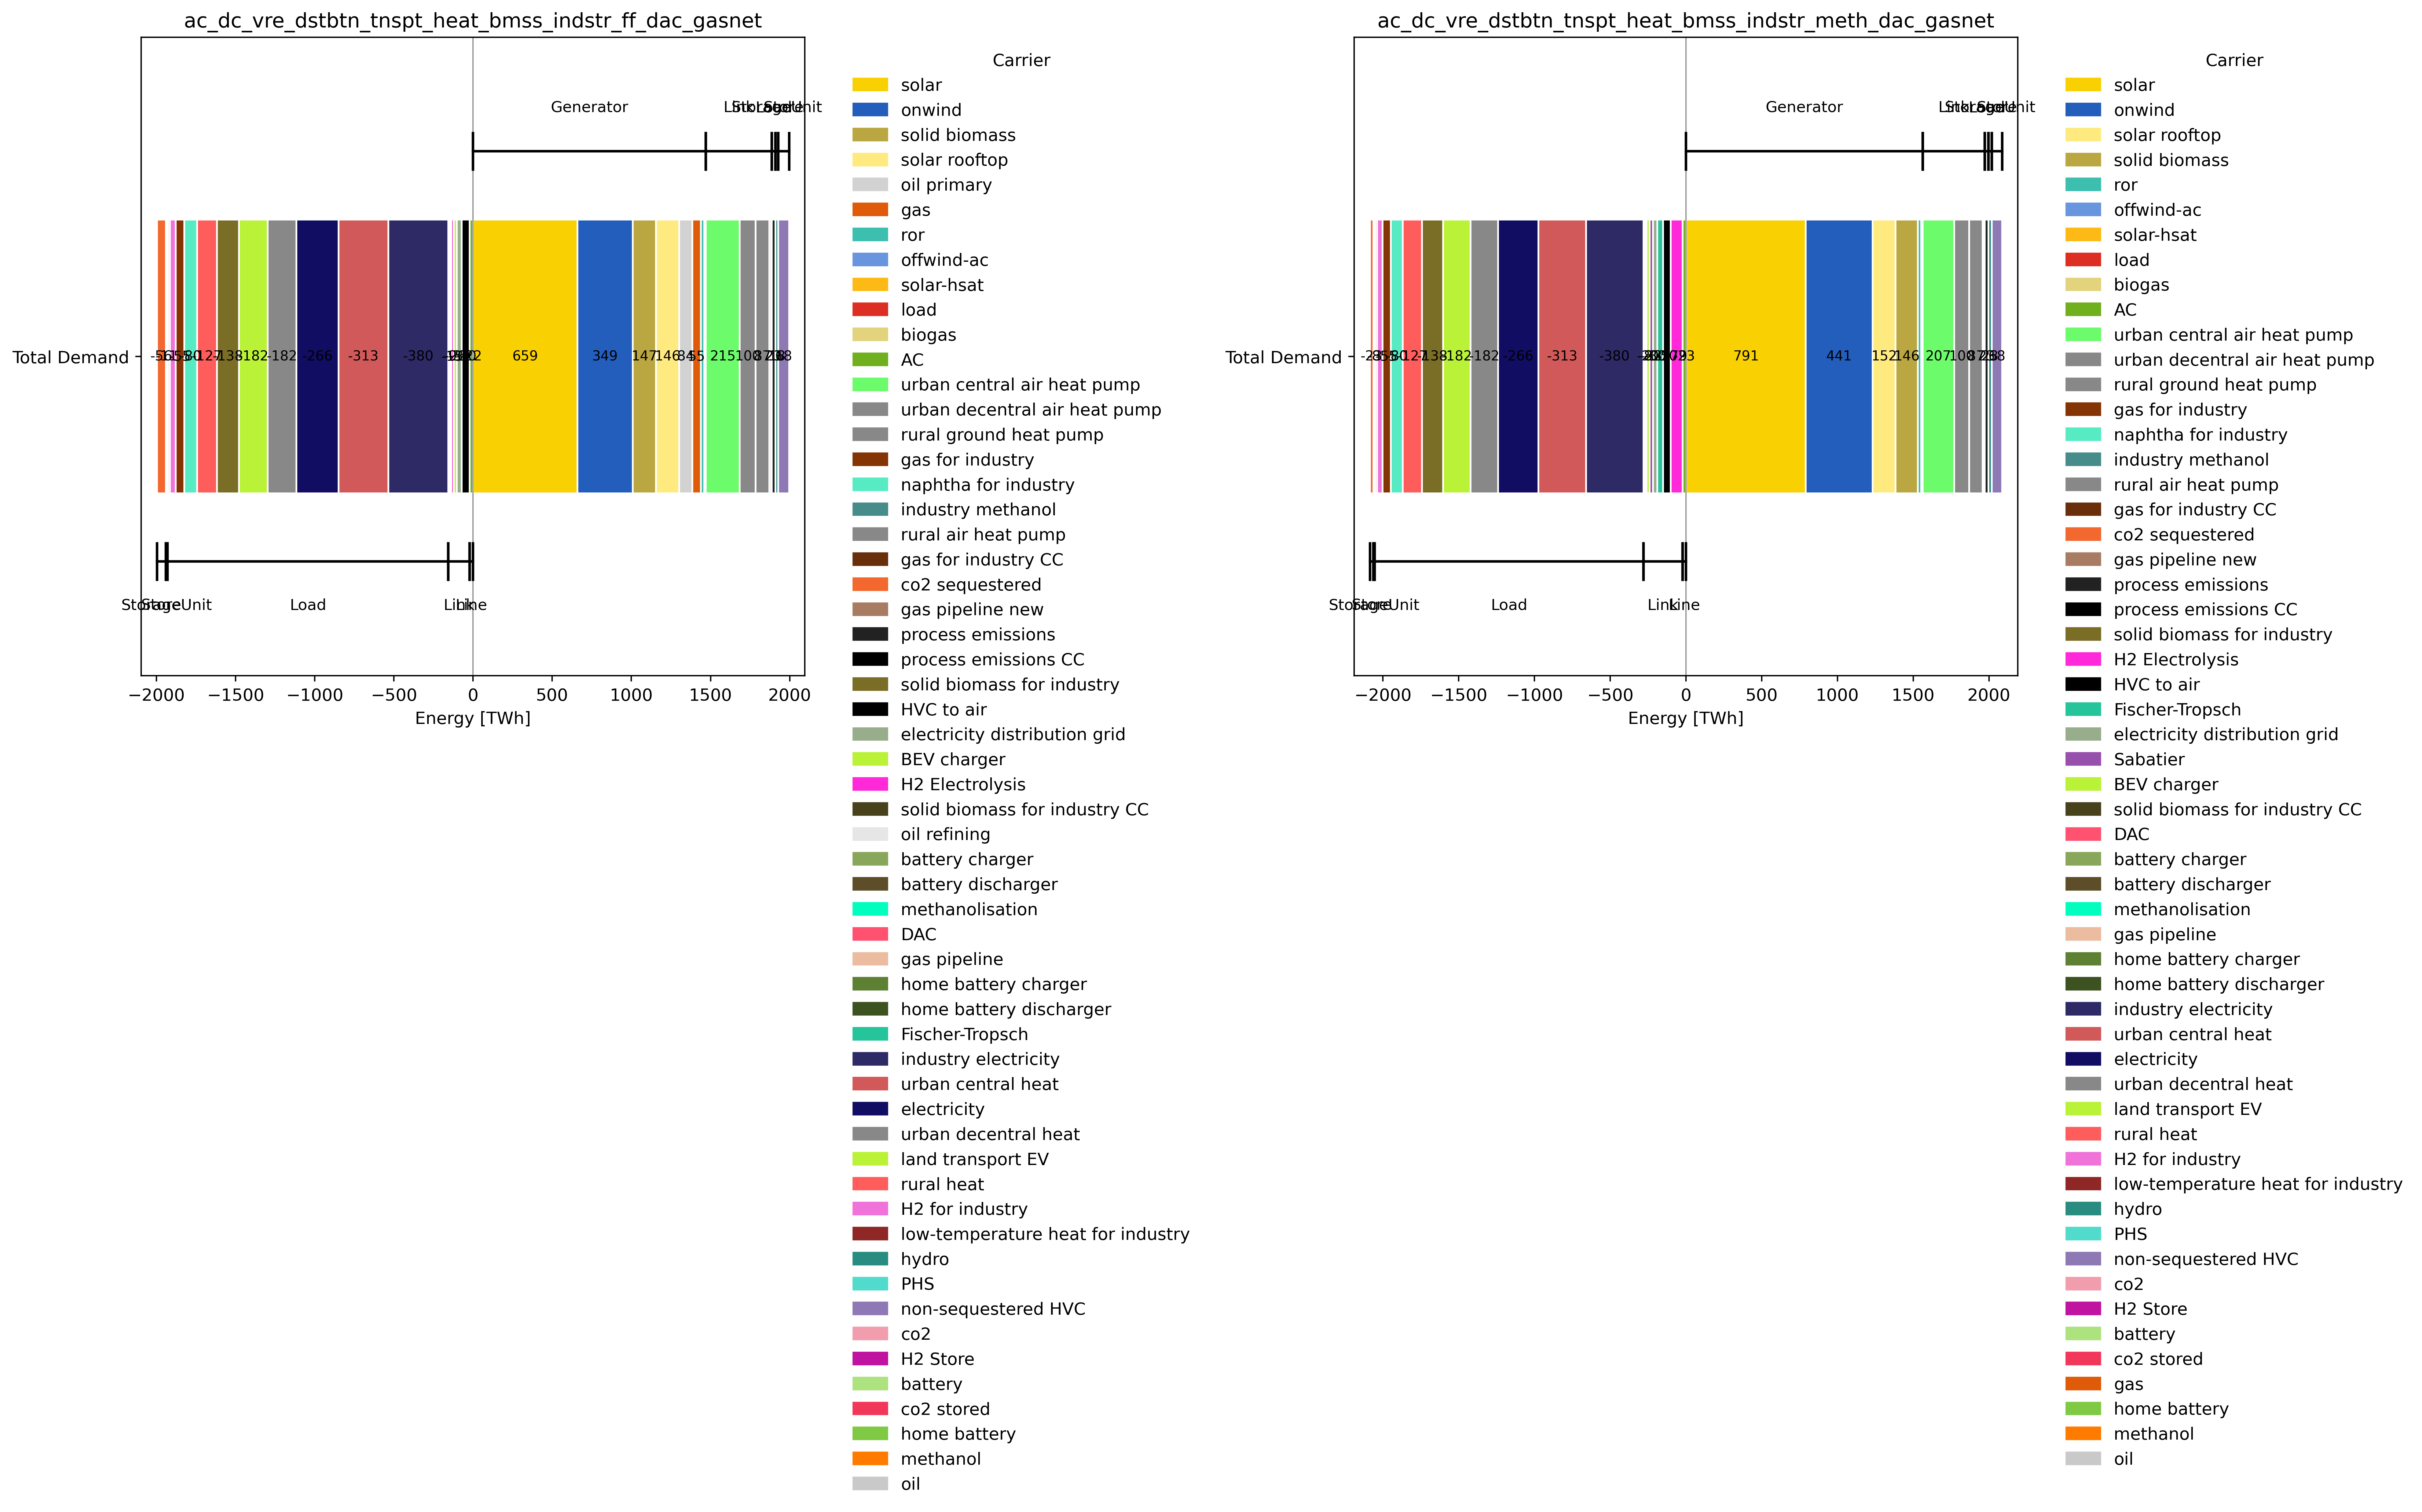

In [21]:
fig, ax = plt.subplots(1, len(runs), figsize=(10 * len(runs), 10))

eb = {}

for i, run in enumerate(runs):
    eb = stats[run].energy_balance(drop_zero=False, nice_names=False, round=3, groupby="carrier")
    # mask = eb.index.get_level_values(1).str.contains("heat")
    # eb_filt = eb[mask]

    stacked_barh_signed(
        eb / 1e6,  # TWh
        ax[i],
        tech_colors=tech_colors,
        y_label="Total Demand",
    )

    ax[i].set_title(f"{run}")
    ax[i].set_xlabel("Energy [TWh]")

plt.show()

### Capacities

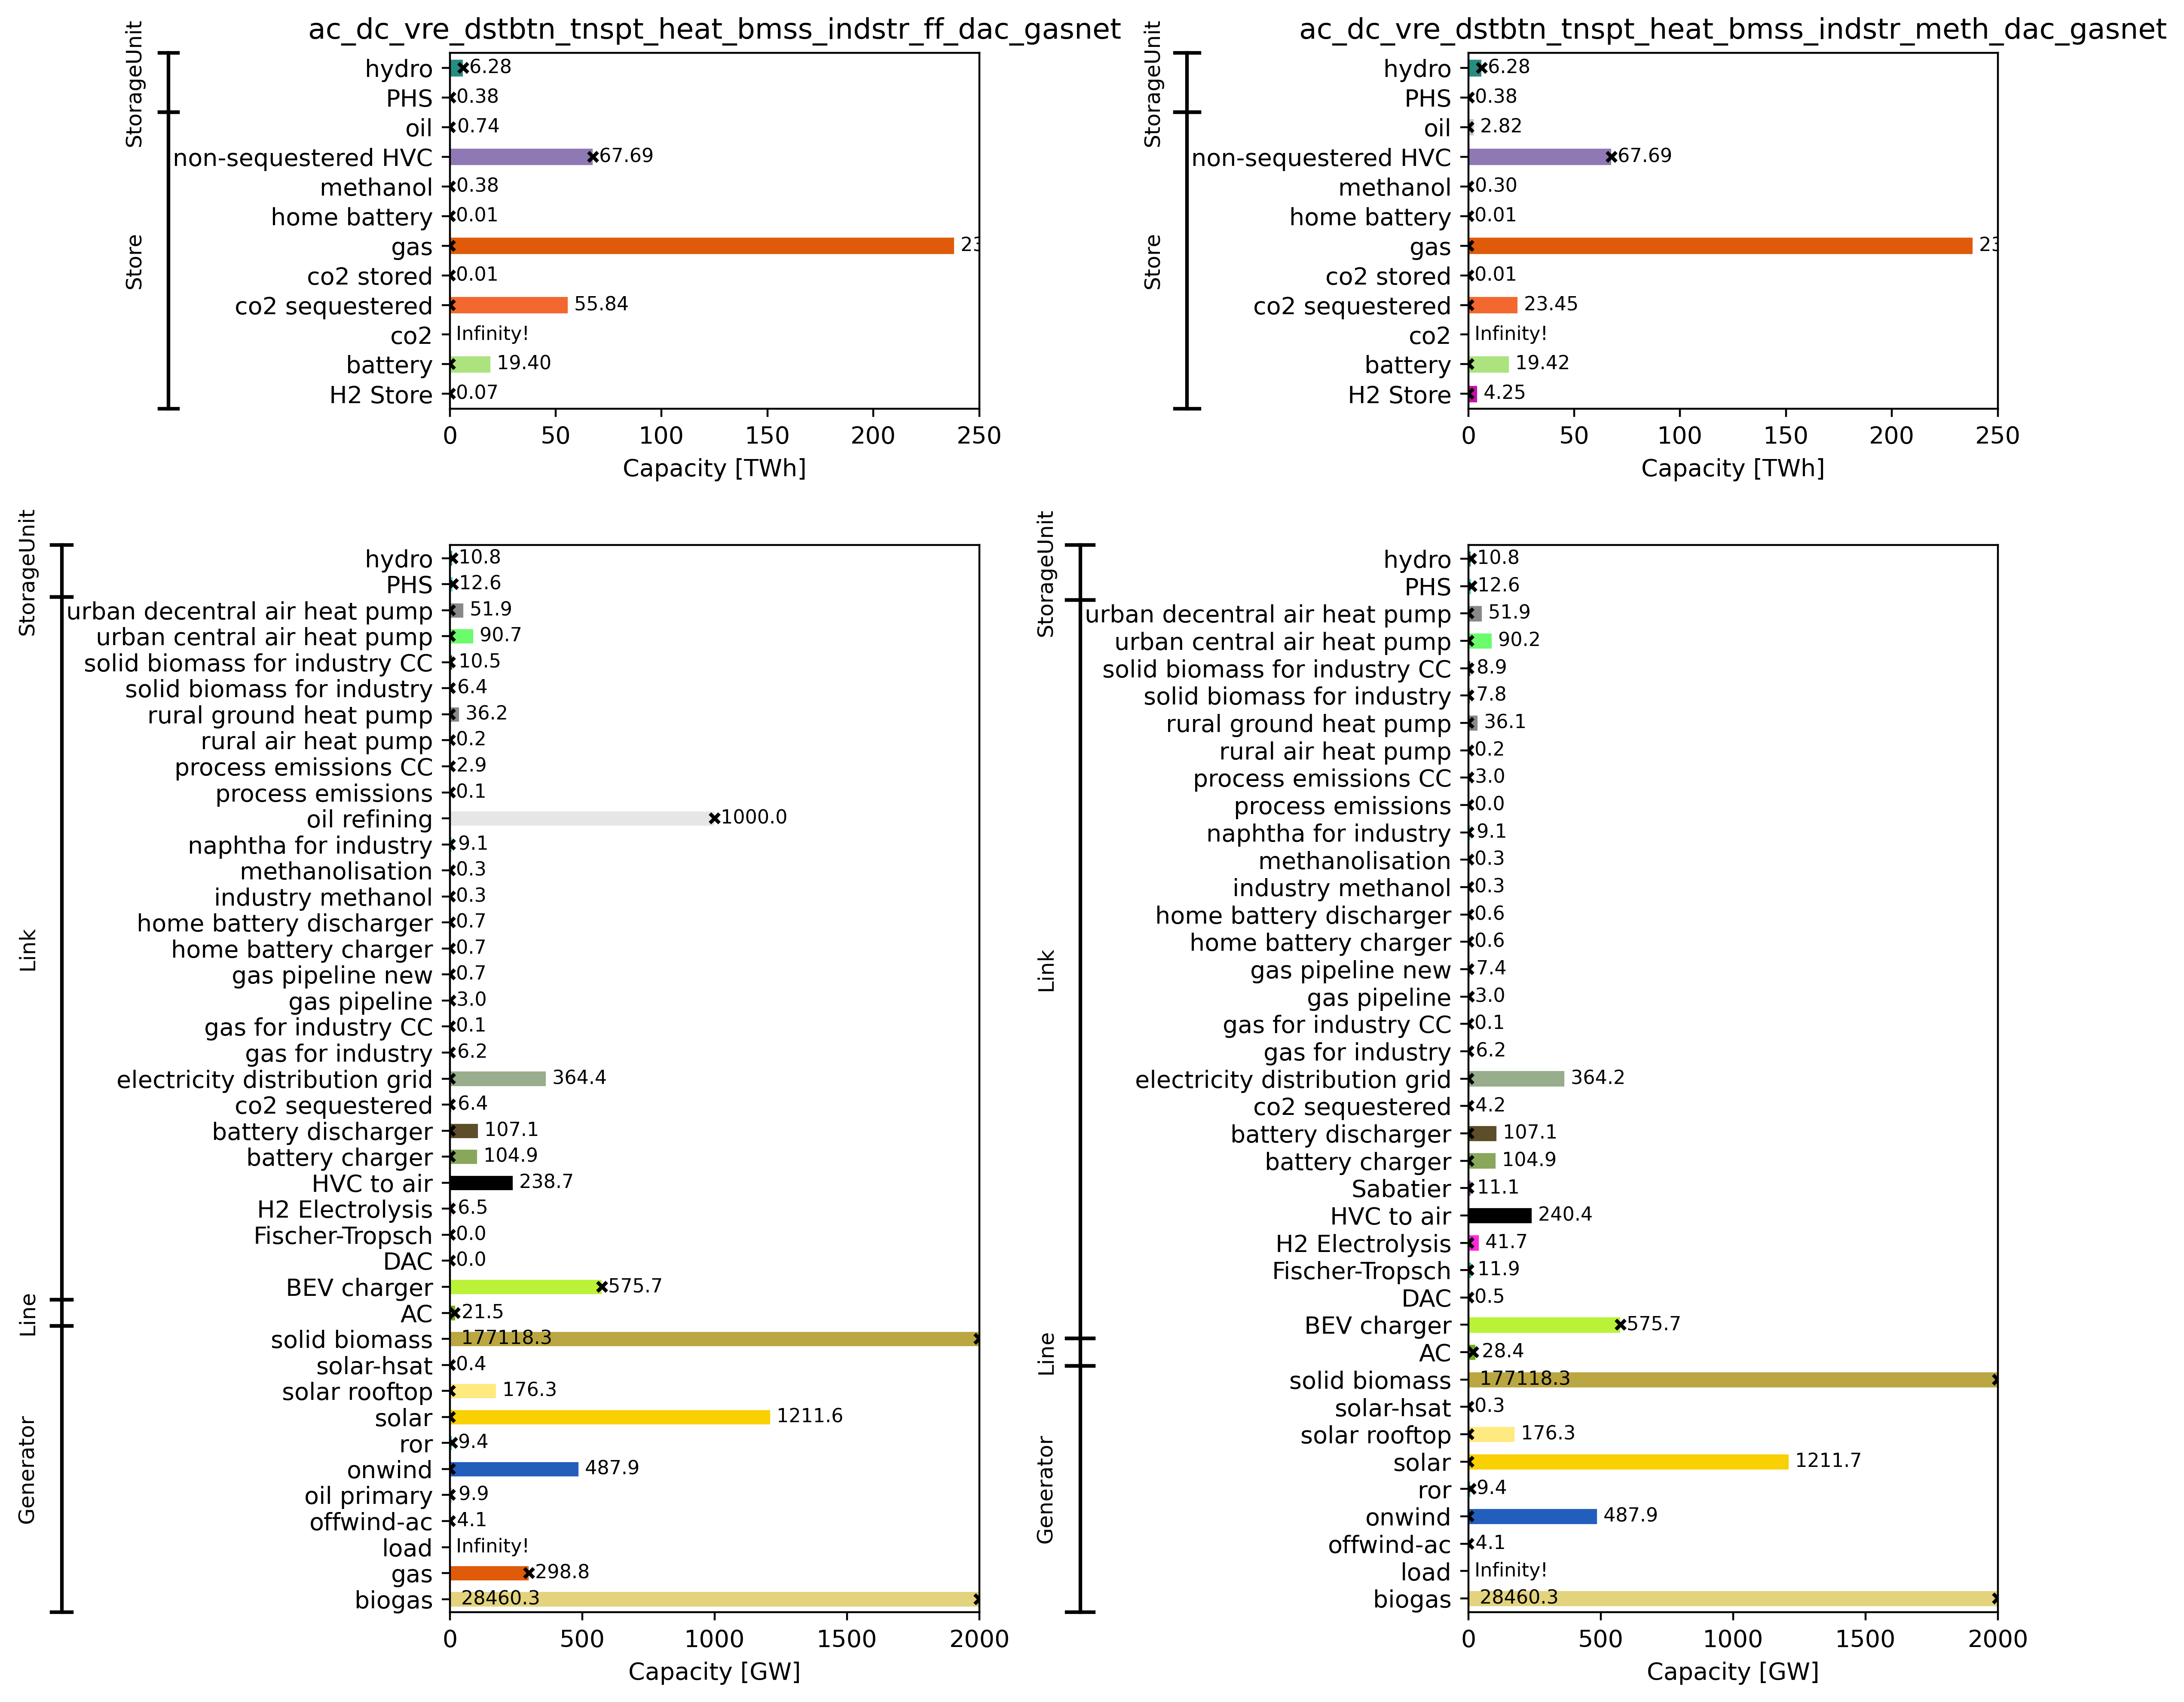

In [22]:
fig, ax = plt.subplots(2, len(runs), figsize=(6 * len(runs), 10), gridspec_kw={"height_ratios": [1, 3]})

capacity_data = {}

for i, run in enumerate(runs):
    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True)
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True)
    energy_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        energy_df / 1e6,  # TWh
        ax[0, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [TWh]",
        title=run,
        annotate_decimals=2,
        show_legend=False,
    )

    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier").drop("Store")
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier").drop("Store")
    power_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        power_df / 1e3,  # GW
        ax[1, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [GW]",
        show_legend=False,
        axis_limit=2000,
    )

plt.tight_layout()
plt.show()

### Costs

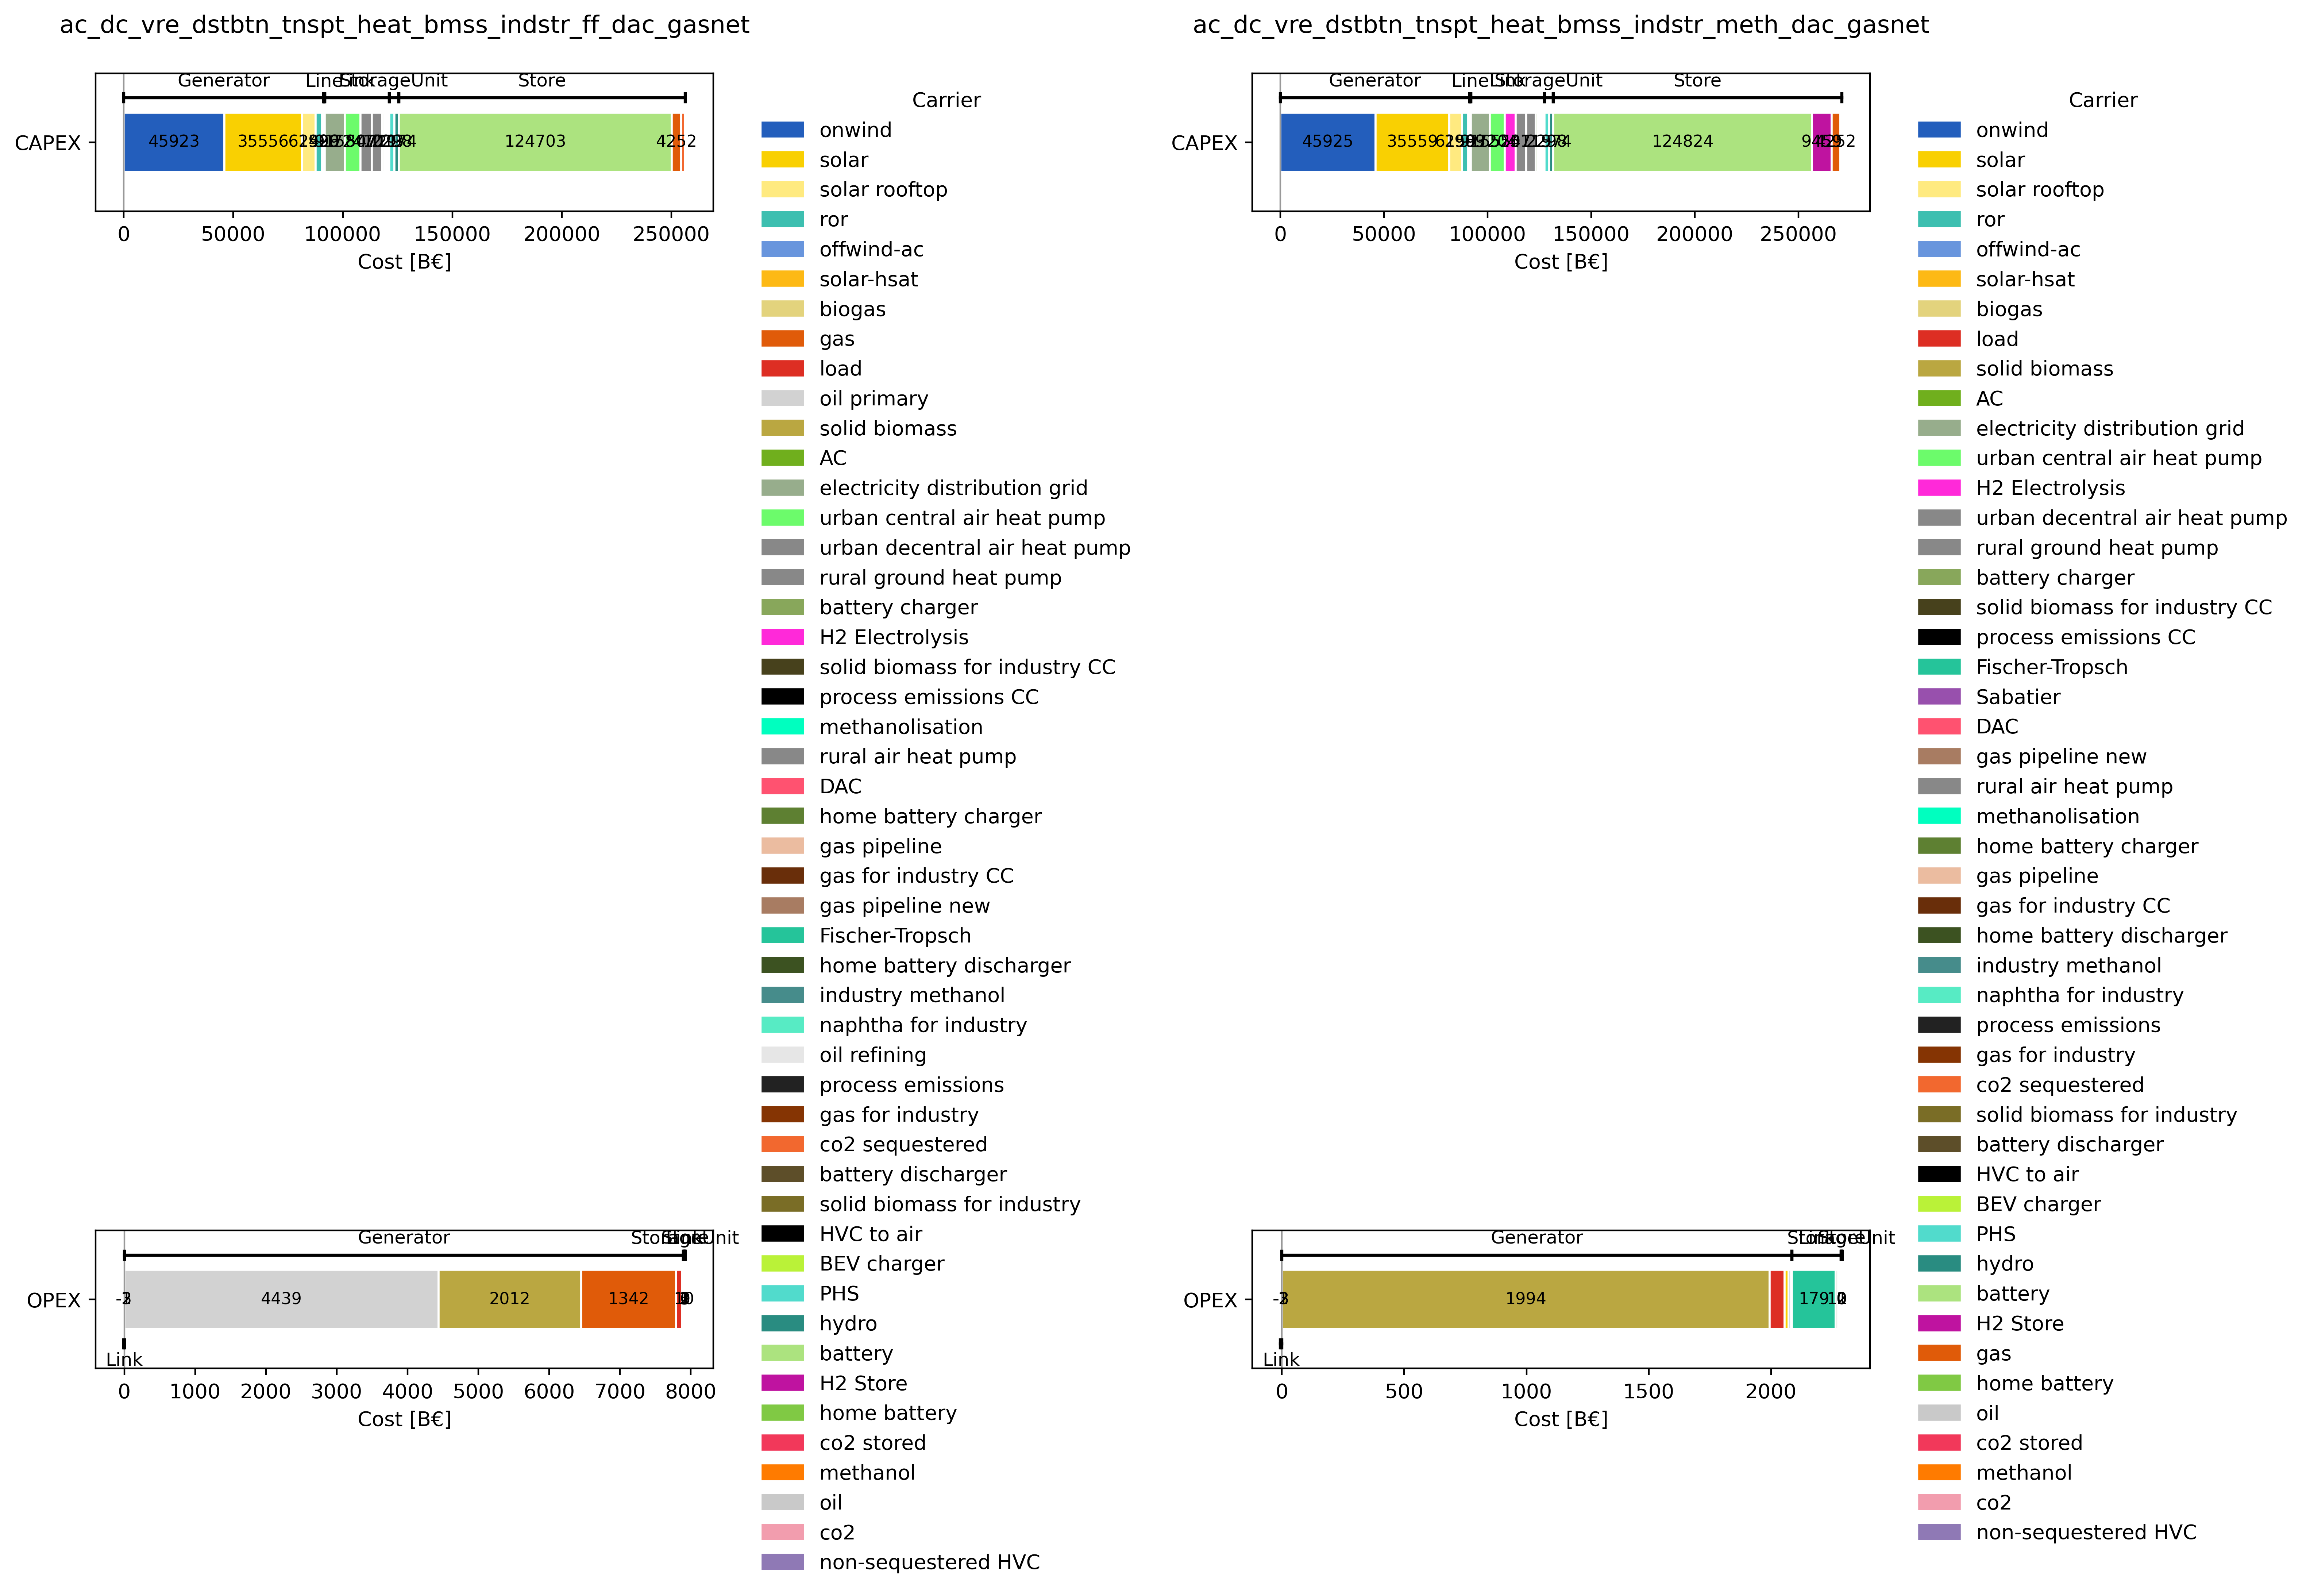

In [29]:
fig, ax = plt.subplots(2, len(runs), figsize=(8 * len(runs), 10))

capex = {}
opex = {}

for i, run in enumerate(runs):
    capex = n[run].statistics()["Capital Expenditure"]
    opex = n[run].statistics()["Operational Expenditure"]
    capex = stats[run].capex(drop_zero=False, nice_names=False, round=3, groupby="carrier")
    opex = stats[run].opex(drop_zero=False, nice_names=False, round=3, groupby="carrier")

    stacked_barh_signed(
        capex / 1e6,  # M€
        ax[0, i],
        tech_colors=tech_colors,
        y_label="CAPEX",
        title=run
    )

    stacked_barh_signed(
        opex / 1e6,  # M€
        ax[1, i],
        tech_colors=tech_colors,
        y_label="OPEX",
        show_legend=False,
    )

    # enforce_common_xlim(ax[:, i], [capex / 1e6, opex / 1e6])

    ax[0, i].set_xlabel("Cost [B€]")
    ax[1, i].set_xlabel("Cost [B€]")

plt.tight_layout()
plt.show()

# Nodes

In [24]:
from pypsa.plot import PlotAccessor

for run in runs:
    print(run)
    plotter = PlotAccessor(n[run])
    plotter.iplot()

ac_dc_vre_dstbtn_tnspt_heat_bmss_indstr_ff_dac_gasnet


ac_dc_vre_dstbtn_tnspt_heat_bmss_indstr_meth_dac_gasnet


# Timeseries

In [25]:
pd.options.display.max_columns = 64
n[run].generators_t.p.sum()

name
CH0 0 0 onwind                     6.878562e+02
DE0 0 0 onwind                     1.836142e+07
DE0 0 0 offwind-ac                 3.673341e+05
CH0 0 0 solar                      6.325152e+06
DE0 0 0 solar                      2.663466e+07
CH0 0 0 solar-hsat                 3.128687e+03
DE0 0 0 solar-hsat                 5.929763e+03
CH0 0 ror                          3.836717e+05
DE0 0 ror                          6.024370e+05
CH0 0 biogas                       0.000000e+00
DE0 0 biogas                       0.000000e+00
EU solid biomass                   6.082131e+06
CH0 0 0 solar rooftop              7.228900e+05
DE0 0 0 solar rooftop              5.609257e+06
CH0 0 load                         7.494158e-01
DE0 0 load                         1.012289e+00
EU load                            0.000000e+00
co2 atmosphere load                0.000000e+00
co2 stored load                    1.034033e+00
co2 sequestered load               2.374309e+00
CH0 0 H2 load                      

Text(0.5, 0, 'Snapshot')

/Users/jopeel/miniconda3/envs/pypsa-eur/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning:

Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.

/Users/jopeel/miniconda3/envs/pypsa-eur/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.



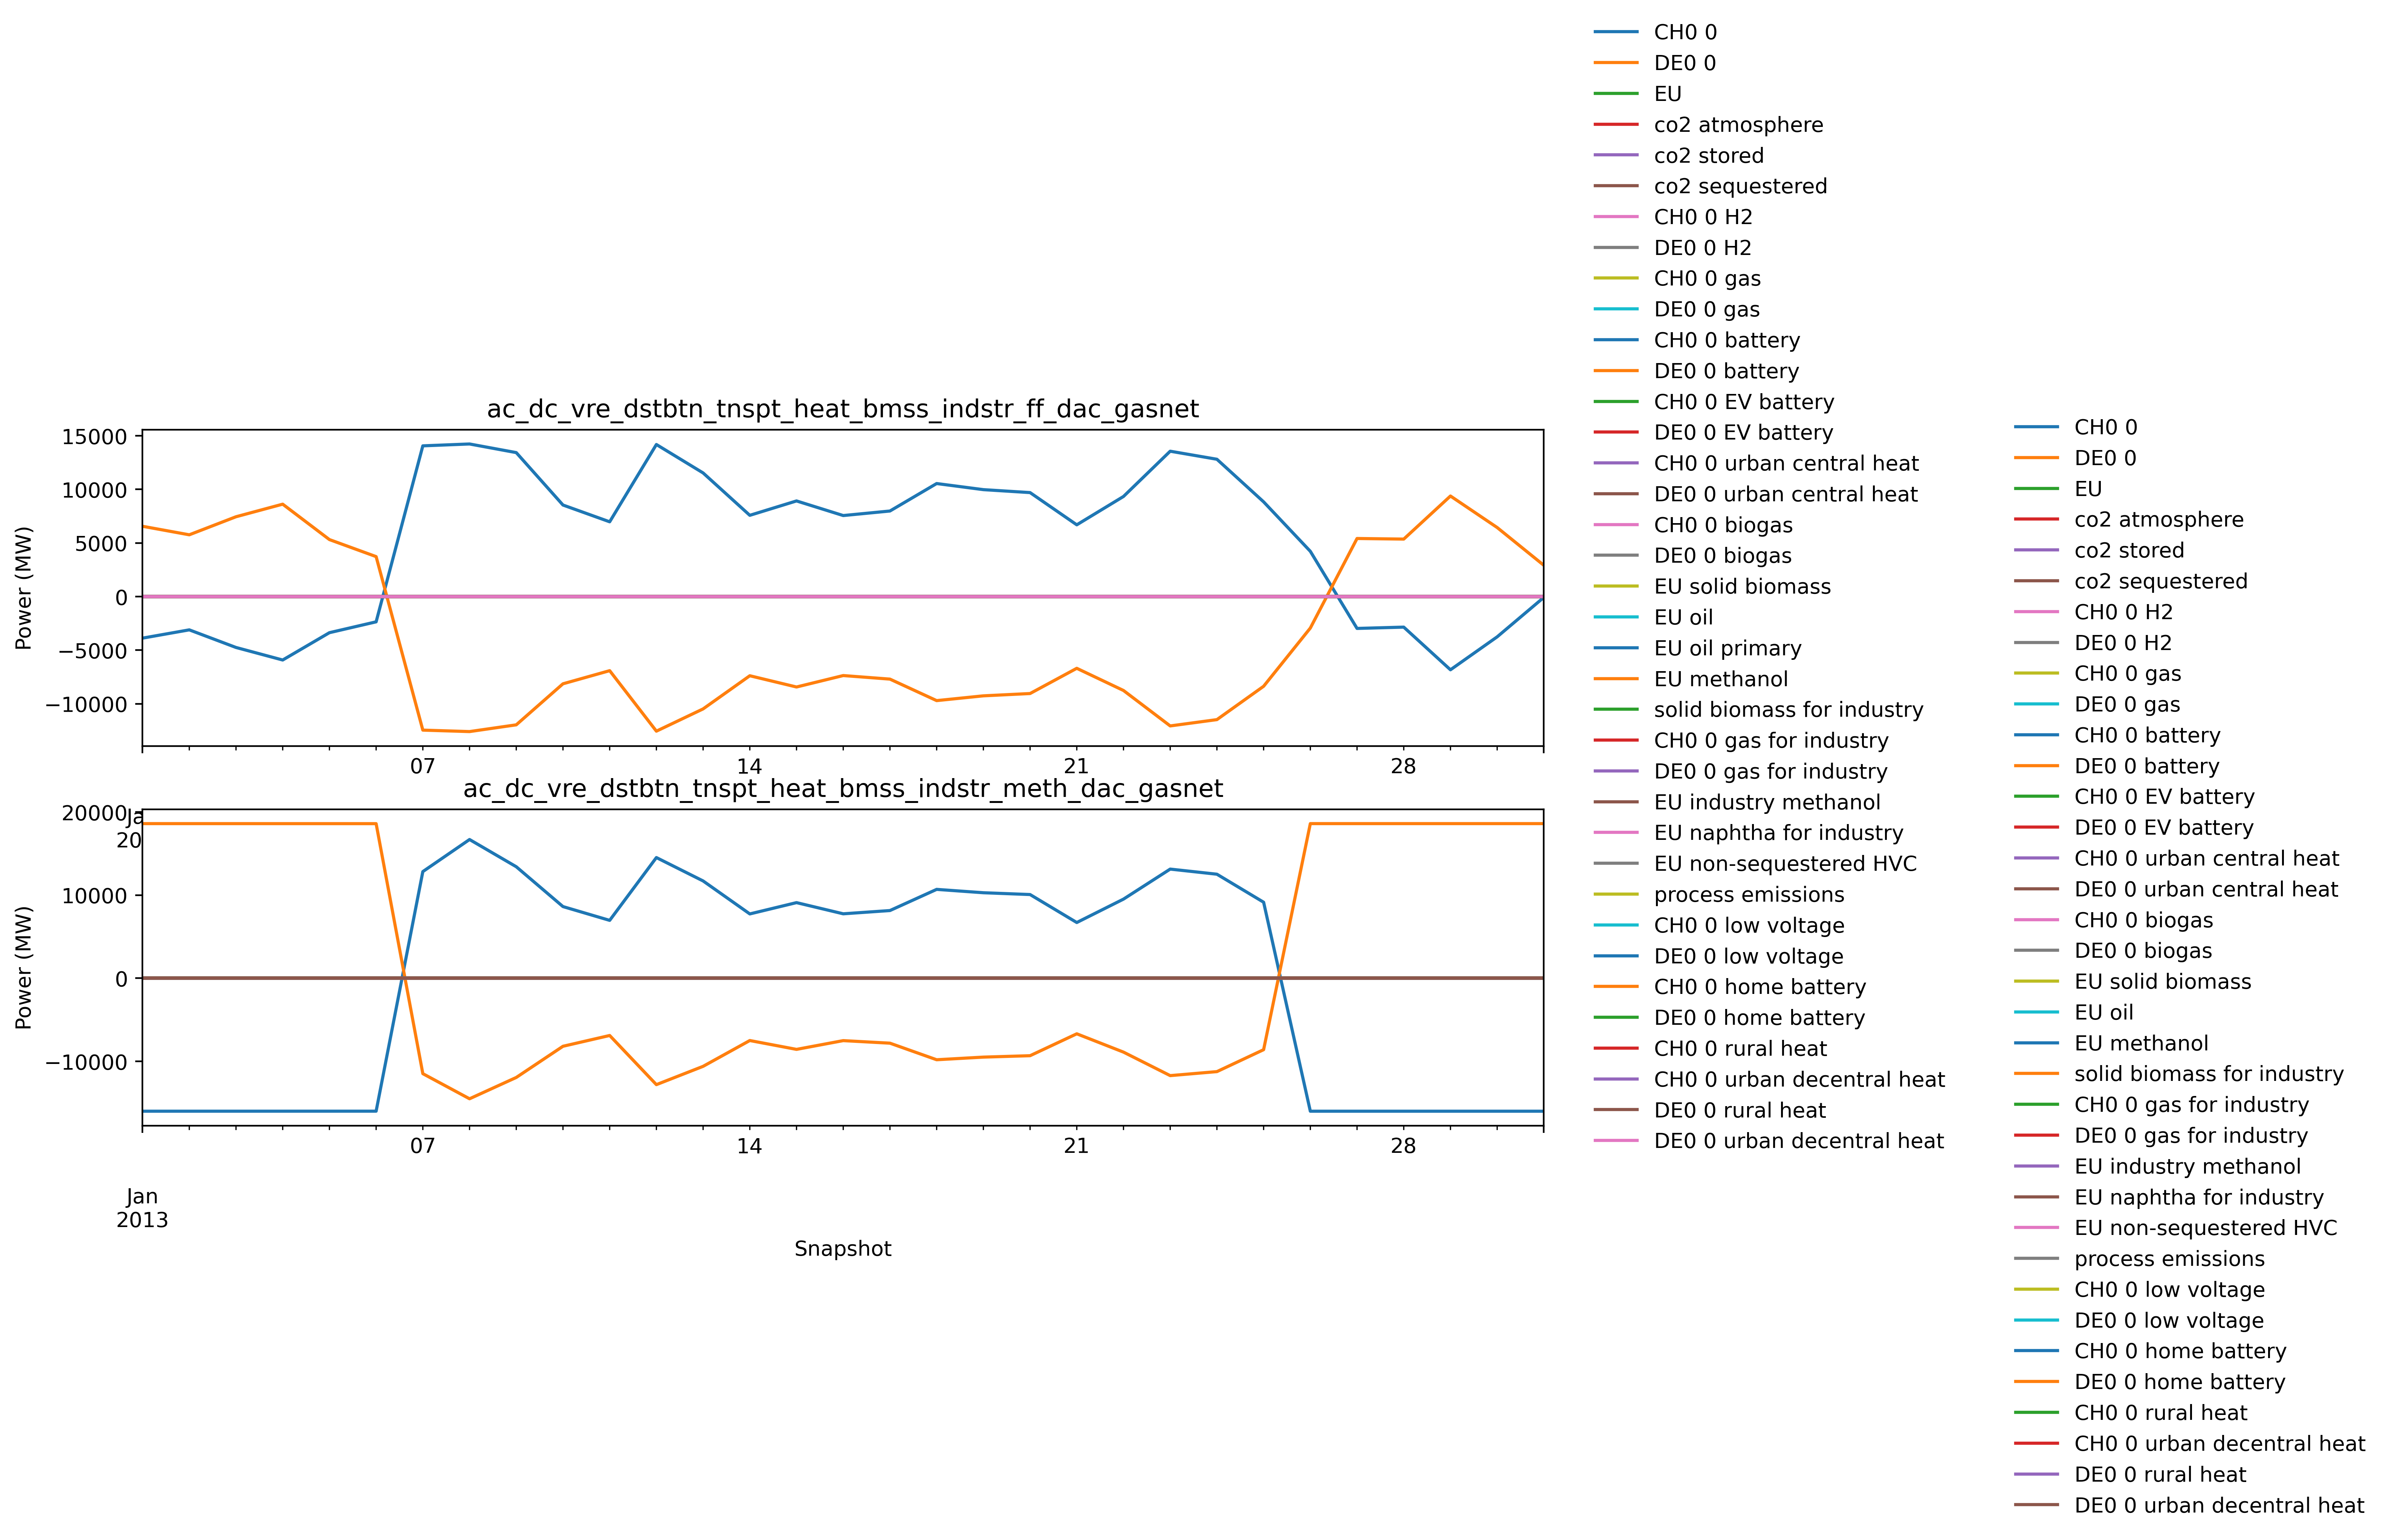

In [26]:
fig, ax = plt.subplots(len(runs), figsize=(12, 6))

time_delta = n[run].buses_t["p"].index.min(), n[run].buses_t["p"].index.min() + pd.Timedelta(days=30)

for i, run in enumerate(runs):
    n[run].buses_t["p"].plot(ax=ax[i])
    ax[i].set_xlim(time_delta)
    ax[i].legend(loc="center right", bbox_to_anchor=(1.3 + i * 0.3, 0.5))
    ax[i].set_xlabel(None)
    ax[i].set_ylabel("Power (MW)")
    ax[i].set_title(run)

ax[-1].set_xlabel("Snapshot")


In [27]:
n[run].loads_t.keys()

dict_keys(['p_set', 'q_set', 'p', 'q'])

KeyError: 'gas for industry'

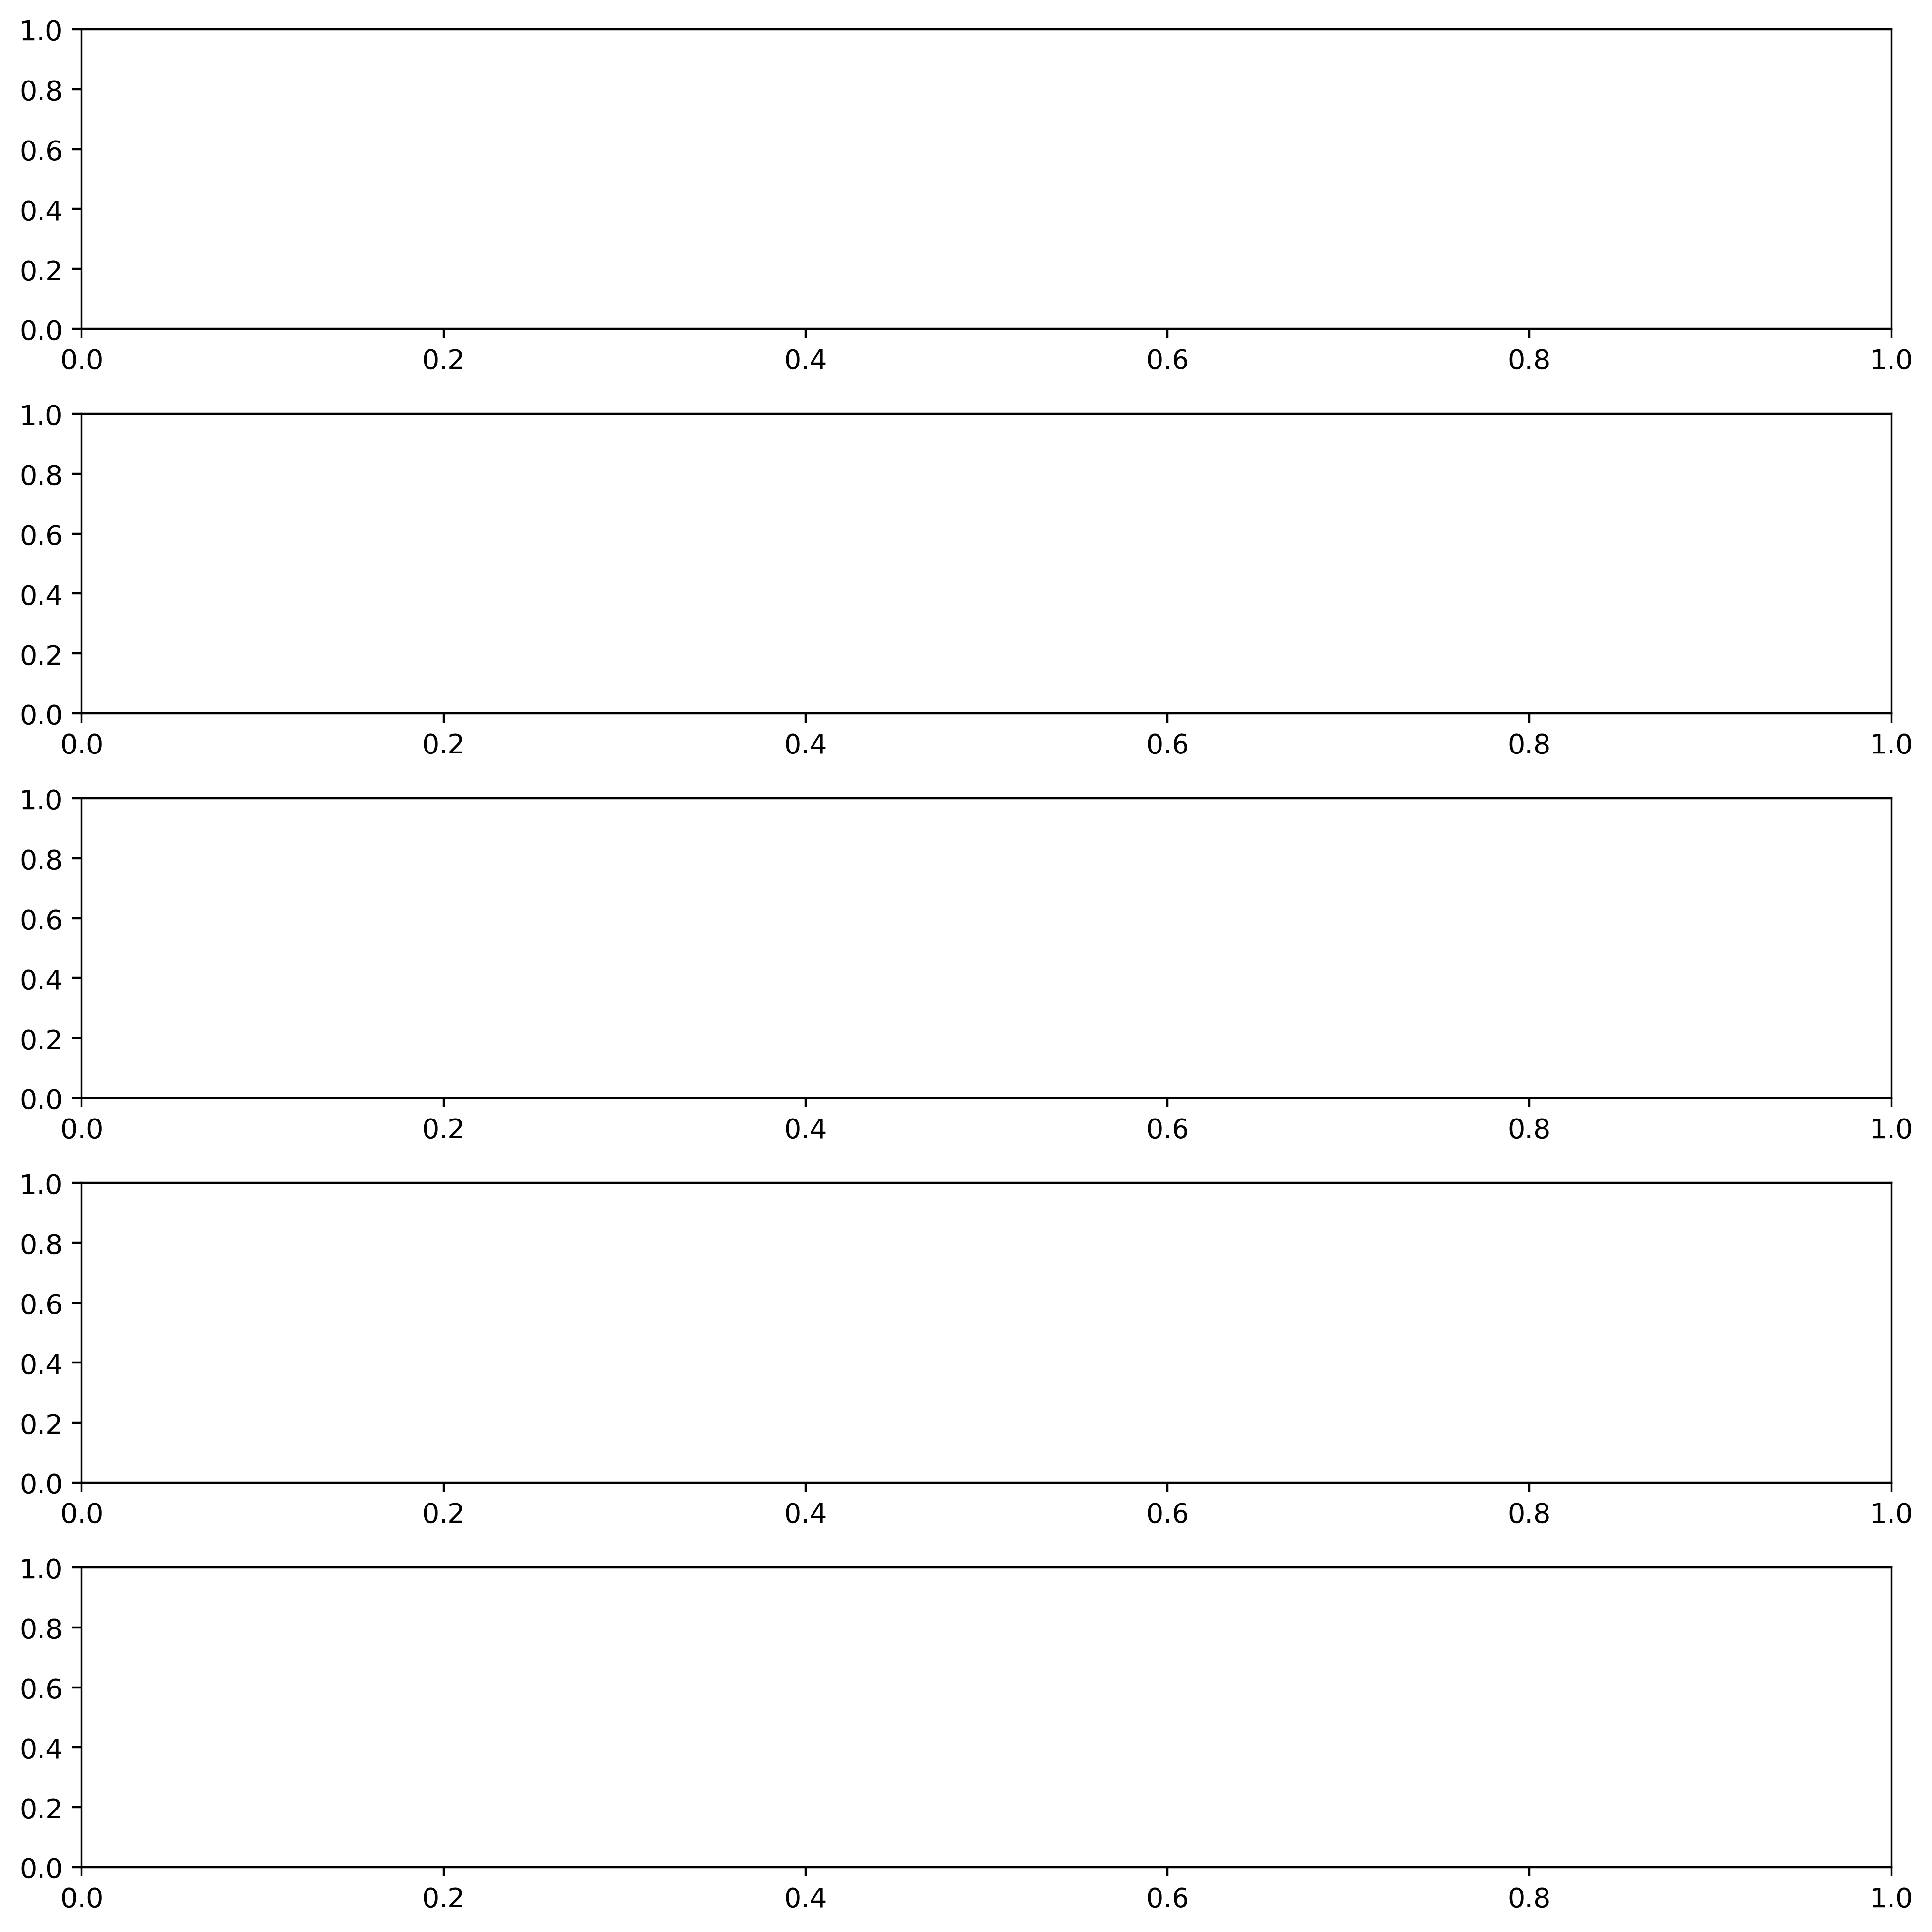

In [28]:
fig, ax = plt.subplots(5, figsize=(10, 10))

n[run].loads_t.p["gas for industry"].plot(ax=ax[0])
n[run].buses_t.p["gas for industry"].plot(ax=ax[1])
n[run].links_t.p0["gas for industry"].plot(ax=ax[2])
n[run].links_t.p1["gas for industry"].plot(ax=ax[3])
n[run].buses_t.p["EU gas"].plot(ax=ax[4])

In [ ]:
n[run].buses.loc["gas for industry"]

v_nom                          1.0
type                              
x                             -5.5
y                             46.0
carrier           gas for industry
unit                       MWh_LHV
location                        EU
v_mag_pu_set                   1.0
v_mag_pu_min                   0.0
v_mag_pu_max                   inf
control                         PQ
generator                         
sub_network                     20
country                           
substation_lv                  NaN
substation_off                 NaN
Name: gas for industry, dtype: object

In [ ]:
n[run].loads.loc["gas for industry"]

bus        gas for industry
carrier    gas for industry
type                       
p_set           6224.885845
q_set                   0.0
sign                   -1.0
active                 True
Name: gas for industry, dtype: object

In [ ]:
n[run].links.loc["gas for industry"]

bus0                                 EU gas
bus1                       gas for industry
type                                       
carrier                    gas for industry
efficiency                              1.0
active                                 True
build_year                                0
lifetime                                inf
p_nom                                   0.0
p_nom_mod                               0.0
p_nom_extendable                       True
p_nom_min                               0.0
p_nom_max                               inf
p_nom_set                               NaN
p_set                                   NaN
p_min_pu                                0.0
p_max_pu                                1.0
capital_cost                            0.0
marginal_cost                      0.010189
marginal_cost_quadratic                 0.0
stand_by_cost                           0.0
length                                  0.0
terrain_factor                  